In [3]:
%pip install requests beautifulsoup4 lxml


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

URL = "https://hooslist.virginia.edu/1262/Group/DataScience"

resp = requests.get(URL, timeout=20)
resp.raise_for_status()

soup = BeautifulSoup(resp.text, "lxml")

rows = []

# Each section row has this class
section_blocks = soup.select(".pb-3")

for block in section_blocks:
    text = block.get_text(" ", strip=True)
    rows.append(text)

df = pd.DataFrame({"raw": rows})
df.head()

,raw
0,DS 1001
1,Foundation of Data Science
2,15256 100 Foundation of Data Science\nLecture ...
3,15257 101 Foundation of Data Science\nLaborato...
4,15296 102 Foundation of Data Science\nLaborato...


In [5]:
import re
import pandas as pd

URL = "https://hooslist.virginia.edu/1262/Group/DataScience"
resp = requests.get(URL, timeout=20)
resp.raise_for_status()
soup = BeautifulSoup(resp.text, "lxml")

blocks = [b.get_text(" ", strip=True) for b in soup.select(".pb-3")]

# patterns
MNEMONIC_RE = re.compile(r"^DS\s+\d{4}$")
SECTION_RE  = re.compile(r"^\d{5}\s+\d{3}\b")
MEETING_RE  = re.compile(r"(?P<days>(?:Mo|Tu|We|Th|Fr|Sa|Su)(?:\|(?:Mo|Tu|We|Th|Fr|Sa|Su))*)\s+"
                         r"(?P<start>\d{1,2}:\d{2}\s*[AP]M)\s*[-–]\s*(?P<end>\d{1,2}:\d{2}\s*[AP]M)")

clean_rows = []
current_mnemonic = None
current_title = None

for text in blocks:
    # header: DS 1001
    if MNEMONIC_RE.match(text):
        current_mnemonic = text
        current_title = None
        continue

    # title line comes right after mnemonic line
    if current_mnemonic and (not SECTION_RE.match(text)) and current_title is None:
        current_title = text
        continue

    # section row
    if SECTION_RE.match(text):
        mmet = MEETING_RE.search(text)
        days = start_time = end_time = None
        instructor = None

        if mmet:
            days = mmet.group("days").replace("|", "")  # Mo|We -> MoWe (optional)
            start_time = mmet.group("start")
            end_time = mmet.group("end")

            # instructor is the last token(s) right before the meeting pattern
            before = text[:mmet.start()].strip()

            # remove enrollment/status noise if present
            before = re.sub(r"\b\d+\s*/\s*\d+\b", "", before)  # 153 / 240
            before = re.sub(r"\b(Open|Closed|Waitlist\s*\(\d+\))\b", "", before).strip()

            # instructor is usually last 2 words, or "TBD"
            if before.endswith("TBD"):
                instructor = "TBD"
            else:
                parts = before.split()
                if len(parts) >= 2:
                    instructor = " ".join(parts[-2:])
                elif parts:
                    instructor = parts[-1]

        clean_rows.append({
            "Course Mnemonic": current_mnemonic,   # DS 1001
            "Course Title": current_title,         # Foundation of Data Science
            "Instructor": instructor,              # Brian Wright / TBD
            "Room": "",                            # leave empty
            "Day(s) of the week": days,
            "Start time": start_time,
            "End time": end_time
        })

df = pd.DataFrame(clean_rows)
df.head(20)

,Course Mnemonic,Course Title,Instructor,Room,Day(s) of the week,Start time,End time
0,DS 1001,Foundation of Data Science,Brian Wright,,MoWe,02:00 PM,03:15 PM
1,DS 1001,Foundation of Data Science,Ali Rivera,,Fr,02:00 PM,02:50 PM
2,DS 1001,Foundation of Data Science,TBD,,Fr,12:00 PM,12:50 PM
3,DS 1001,Foundation of Data Science,Ali Rivera,,Fr,01:00 PM,01:50 PM
4,DS 1001,Foundation of Data Science,TBD,,Fr,12:00 PM,12:50 PM
5,DS 1001,Foundation of Data Science,TBD,,Fr,01:00 PM,01:50 PM
6,DS 1002,Programming for Data Science,Mai Dahshan,,MoWe,03:30 PM,04:45 PM
7,DS 1002,Programming for Data Science,Mai Dahshan,,TuTh,02:00 PM,03:15 PM
8,DS 2002,Data Science Systems,Jon Tupitza,,MoWeFr,09:00 AM,09:50 AM
9,DS 2002,Data Science Systems,Jason Williamson,,MoWeFr,10:00 AM,10:50 AM


In [6]:
# Convert times to time objects (overwrite original columns)

df["Start time"] = pd.to_datetime(
    df["Start time"], format="%I:%M %p"
).dt.time

df["End time"] = pd.to_datetime(
    df["End time"], format="%I:%M %p"
).dt.time

df.head(100)

,Course Mnemonic,Course Title,Instructor,Room,Day(s) of the week,Start time,End time
0,DS 1001,Foundation of Data Science,Brian Wright,,MoWe,14:00:00,15:15:00
1,DS 1001,Foundation of Data Science,Ali Rivera,,Fr,14:00:00,14:50:00
2,DS 1001,Foundation of Data Science,TBD,,Fr,12:00:00,12:50:00
3,DS 1001,Foundation of Data Science,Ali Rivera,,Fr,13:00:00,13:50:00
4,DS 1001,Foundation of Data Science,TBD,,Fr,12:00:00,12:50:00
...,...,...,...,...,...,...,...
95,DS 8998,Master's Level Thesis Research,NaN,,NaN,NaT,NaT
96,DS 8998,Master's Level Thesis Research,NaN,,NaN,NaT,NaT
97,DS 8998,Master's Level Thesis Research,NaN,,NaN,NaT,NaT
98,DS 8998,Master's Level Thesis Research,NaN,,NaN,NaT,NaT


In [7]:
# save data
df.to_csv("ds_courses.csv", index=False)

### Plots (2 histograms)

In [10]:
import matplotlib.pyplot as plt

In [11]:
print("Total rows:", len(df))
print("Missing start times:", df["Start time"].isna().sum())

Total rows: 169
Missing start times: 101


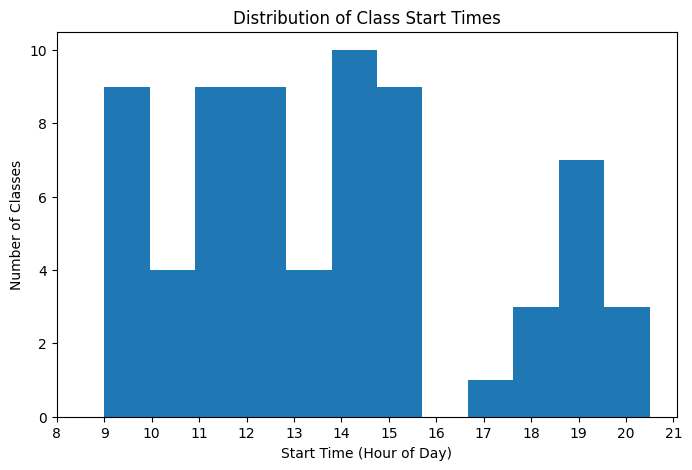

In [12]:
# Histogram: Class Times
# Note: Removing values with NaT (not a time): These are Thesis Research, Independent Study, etc. 101 rows removed. 

# drop rows with missing start times
plot_df = df.dropna(subset=["Start time"]).copy()

# convert time objects to numeric hour values
plot_df["Start_hour"] = plot_df["Start time"].apply(
    lambda t: t.hour + t.minute / 60
)

# plot histogram
plt.figure(figsize=(8,5))
plt.hist(plot_df["Start_hour"], bins=12)

plt.xlabel("Start Time (Hour of Day)")
plt.ylabel("Number of Classes")
plt.title("Distribution of Class Start Times")

plt.xticks(range(8, 22)) 
plt.show()



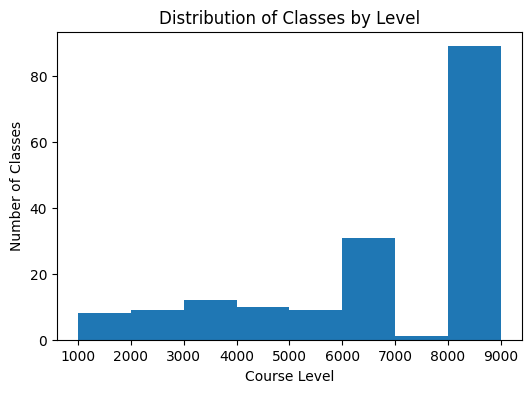

In [13]:
# Course Number histogram


# extract course number (numeric)
df["Course_Number"] = df["Course Mnemonic"].str.extract(r"(\d+)").astype(int)

# create level (1xxx, 2xxx, etc.)
df["Level"] = (df["Course_Number"] // 1000) * 1000

# plot histogram
plt.figure(figsize=(6,4))
plt.hist(df["Level"], bins=range(1000, 10000, 1000))

plt.xlabel("Course Level")
plt.ylabel("Number of Classes")
plt.title("Distribution of Classes by Level")

plt.xticks(range(1000, 10000, 1000))
plt.show()